Branch 1 — Fear & Volatility
Date range : 1990-01-02 -> 2026-03-13

Coverage per indicator:
  VIX Index            10283 days  1990-01-02 -> 2026-03-13  Current: 27.19  Mean: 19.37  Max: 82.69
  VIX9D Index           4045 days  2011-01-03 -> 2026-03-13  Current: 28.00  Mean: 17.41  Max: 106.66
  VIX3M Index           6570 days  2002-01-02 -> 2026-03-13  Current: 27.28  Mean: 20.79  Max: 72.98
  VIX6M Index           4844 days  2008-01-02 -> 2026-03-13  Current: 27.43  Mean: 22.90  Max: 61.47
  V2X Index             7458 days  1999-01-04 -> 2026-03-13  Current: 30.33  Mean: 23.20  Max: 87.51
  V1X Index             9652 days  1992-01-02 -> 2026-03-13  Current: 29.07  Mean: 22.02  Max: 86.01
  VNKY Index            6864 days  2001-01-04 -> 2026-03-13  Current: 45.80  Mean: 24.06  Max: 92.03
  VHSI Index            6878 days  2001-01-02 -> 2026-03-13  Current: 26.42  Mean: 22.93  Max: 104.29
  MOVE Index           10285 days  1990-01-02 -> 2026-03-13  Current: 91.17  Mean: 93.09  Max: 264

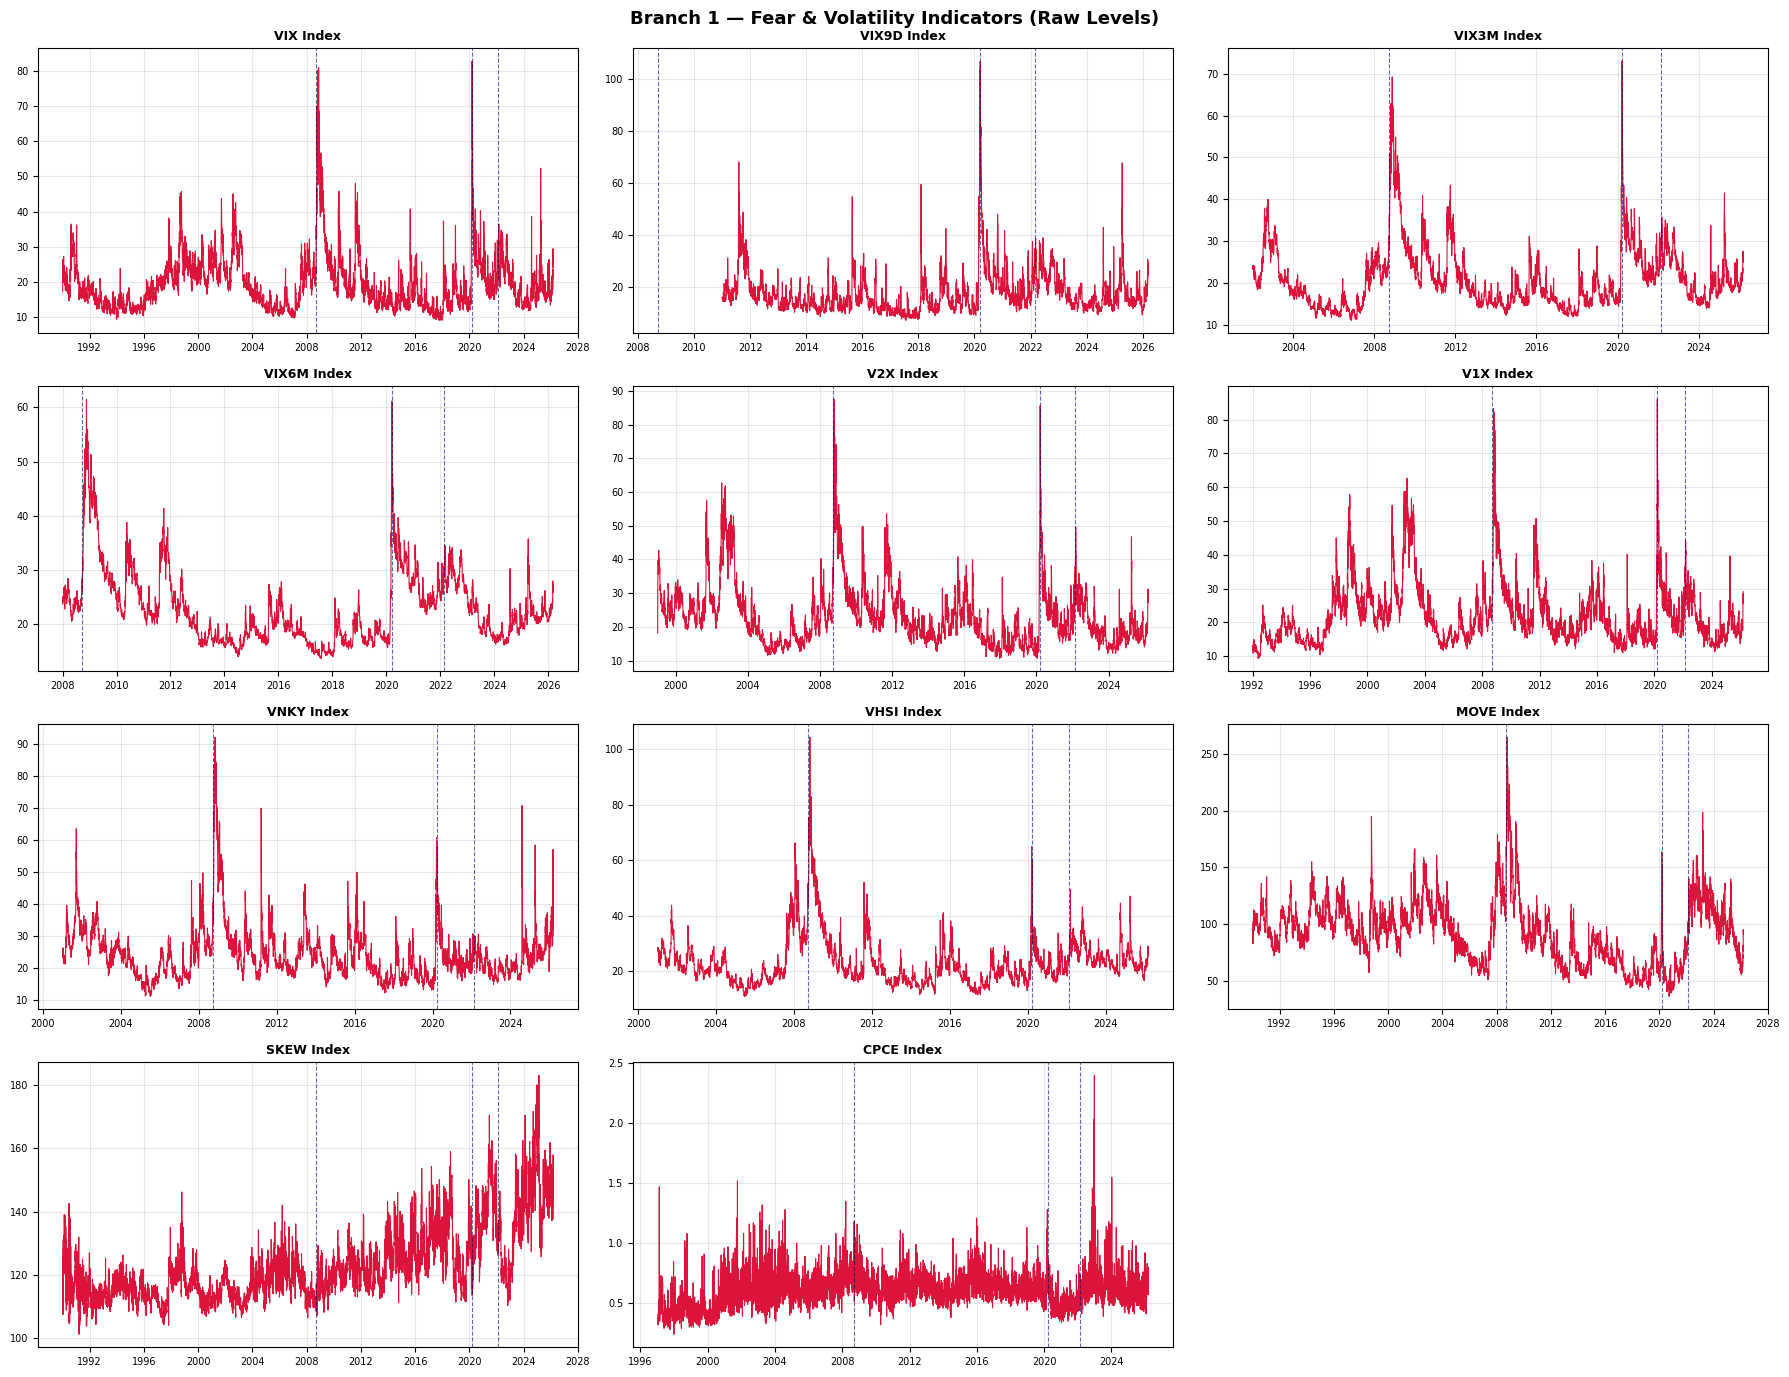


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\02_branch1_raw_levels.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load master returns ───────────────────────────────────────────────────────
returns = pd.read_csv(cfg.MASTER_RETURNS_FILE, index_col="date", parse_dates=True)
prices  = pd.read_csv(cfg.ALIGNED_PRICES_FILE, index_col="date", parse_dates=True)

# ── Branch 1 tickers ─────────────────────────────────────────────────────────
FEAR_TICKERS = [
    "VIX Index",   # US 30D implied vol — the main fear gauge
    "VIX9D Index", # US 9D implied vol  — very short term fear
    "VIX3M Index", # US 3M implied vol  — medium term
    "VIX6M Index", # US 6M implied vol  — longer term
    "V2X Index",   # Euro Stoxx vol
    "V1X Index",   # VDAX-NEW German vol
    "VNKY Index",  # Nikkei vol
    "VHSI Index",  # Hang Seng vol
    "MOVE Index",  # Bond market vol
    "SKEW Index",  # Tail risk / left tail hedging
    "CPCE Index",  # Put/Call ratio
]

# ── Extract price levels for fear indicators ──────────────────────────────────
# For vol indices we want LEVELS not returns — fear is measured in absolute terms
fear_levels = prices[FEAR_TICKERS].copy()
fear_levels.dropna(how="all", inplace=True)

print("Branch 1 — Fear & Volatility")
print("="*55)
print(f"Date range : {fear_levels.index.min().date()} -> {fear_levels.index.max().date()}")
print()
print("Coverage per indicator:")
for col in FEAR_TICKERS:
    s = fear_levels[col].dropna()
    print(f"  {col:<20} {len(s):>5} days  "
          f"{str(s.index.min().date())} -> {str(s.index.max().date())}  "
          f"Current: {s.iloc[-1]:.2f}  "
          f"Mean: {s.mean():.2f}  "
          f"Max: {s.max():.2f}")

# ── Plot all fear indicators ──────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(FEAR_TICKERS):
    s = fear_levels[col].dropna()
    ax = axes[idx]
    ax.plot(s.index, s.values, lw=0.8, color="crimson")
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

    # Mark key crisis dates
    for crisis_date, label in [("2008-09-15","GFC"), ("2020-03-16","Covid"), ("2022-02-24","Ukraine")]:
        try:
            ax.axvline(pd.Timestamp(crisis_date), color="navy", lw=0.8, ls="--", alpha=0.6)
        except:
            pass

# Hide the unused 12th subplot
axes[-1].set_visible(False)

fig.suptitle("Branch 1 — Fear & Volatility Indicators (Raw Levels)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "02_branch1_raw_levels.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

Z-score stats (last available value per indicator):
-------------------------------------------------------
  VIX Index            Z =  +1.52  [ELEVATED]
  VIX9D Index          Z =  +1.36  [ELEVATED]
  VIX3M Index          Z =  +1.75  [ELEVATED]
  VIX6M Index          Z =  +1.92  [ELEVATED]
  V2X Index            Z =  +2.38  [ACUTE]
  V1X Index            Z =  +2.46  [ACUTE]
  VNKY Index           Z =  +2.87  [ACUTE]
  VHSI Index           Z =  +0.95  [NORMAL]
  MOVE Index           Z =  +0.58  [NORMAL]
  SKEW Index           Z =  -1.04  [CALM]
  CPCE Index           Z =  -0.08  [NORMAL]

VIX Term Structure as of 2026-03-13:
  VIX9D  : 28.00
  VIX30D : 27.19
  VIX3M  : 27.28
  VIX6M  : 27.43
  Slope  : +0.57  (INVERTED — acute stress)

Global Fear Score as of 2026-03-13:
  Score  : 83.1 / 100
  Regime : ACUTE

Regime distribution over full history:
Global Fear Score
CALM        3589
ELEVATED    2655
NORMAL      2629
ACUTE       1412


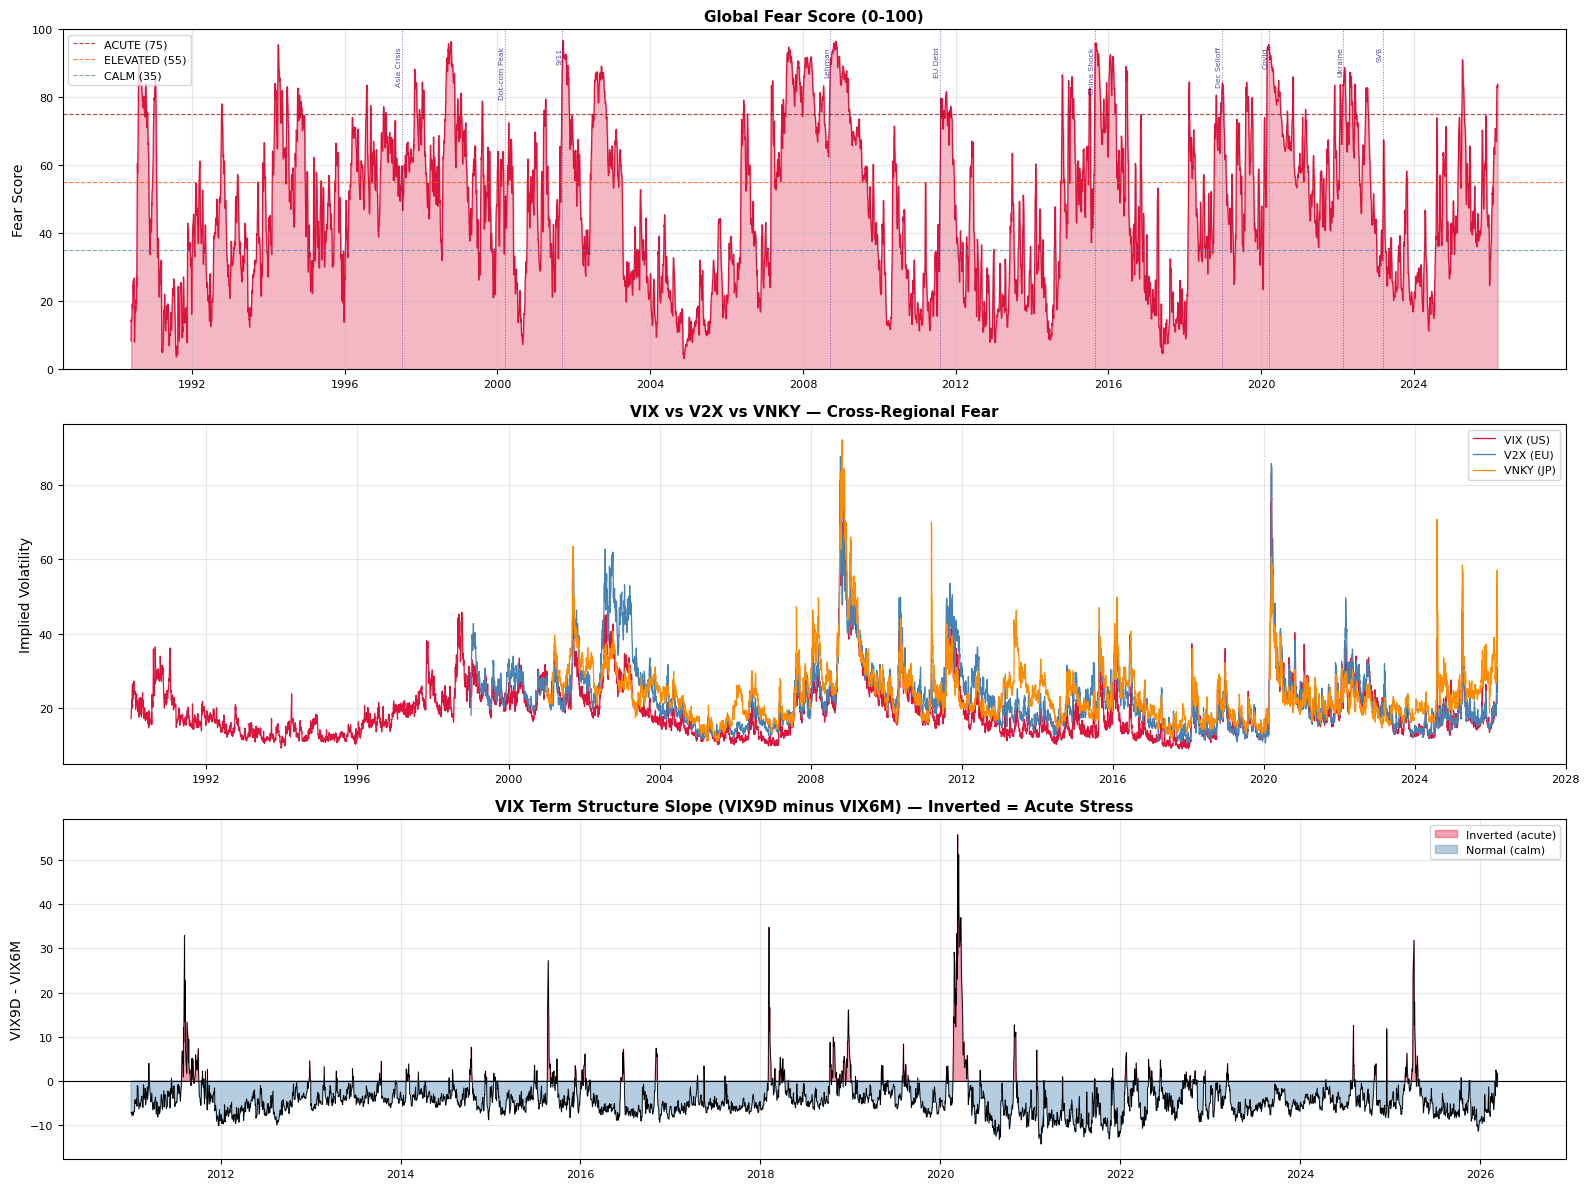


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\02_branch1_fear_score.png
Branch 1 output saved.


In [2]:
# ── Step 2: Z-scores, VIX term structure, Global Fear Score ──────────────────

# ── 2A: Rolling Z-scores ─────────────────────────────────────────────────────
# Z-score = (current - rolling mean) / rolling std
# This tells us how elevated each indicator is relative to its own recent history
# We use a 1-year (252 day) rolling window

ZSCORE_WINDOW = 252

fear_zscore = pd.DataFrame(index=fear_levels.index)

for col in FEAR_TICKERS:
    s                    = fear_levels[col]
    rolling_mean         = s.rolling(ZSCORE_WINDOW, min_periods=63).mean()
    rolling_std          = s.rolling(ZSCORE_WINDOW, min_periods=63).std()
    fear_zscore[col]     = (s - rolling_mean) / rolling_std

print("Z-score stats (last available value per indicator):")
print("-"*55)
for col in FEAR_TICKERS:
    z = fear_zscore[col].dropna()
    if not z.empty:
        current_z = z.iloc[-1]
        regime    = "ACUTE" if current_z > 2 else "ELEVATED" if current_z > 1 else "CALM" if current_z < -0.5 else "NORMAL"
        print(f"  {col:<20} Z = {current_z:>+6.2f}  [{regime}]")


# ── 2B: VIX term structure ────────────────────────────────────────────────────
# Shape of the VIX curve tells us about the TYPE of fear
# Normal (upward slope): VIX9D < VIX < VIX3M < VIX6M — calm, uncertainty is in future
# Inverted (downward slope): VIX9D > VIX3M > VIX6M — ACUTE current stress
# The slope is: VIX9D minus VIX6M

vix_tickers_for_term = ["VIX9D Index", "VIX Index", "VIX3M Index", "VIX6M Index"]
term_structure        = fear_levels[vix_tickers_for_term].dropna()

# Term structure slope: negative = inverted = acute fear
term_slope = term_structure["VIX9D Index"] - term_structure["VIX6M Index"]

# Current term structure
latest_date = term_structure.dropna().index[-1]
latest_vals = term_structure.loc[latest_date]
current_slope = term_slope.loc[latest_date]

print(f"\nVIX Term Structure as of {latest_date.date()}:")
print(f"  VIX9D  : {latest_vals['VIX9D Index']:.2f}")
print(f"  VIX30D : {latest_vals['VIX Index']:.2f}")
print(f"  VIX3M  : {latest_vals['VIX3M Index']:.2f}")
print(f"  VIX6M  : {latest_vals['VIX6M Index']:.2f}")
print(f"  Slope  : {current_slope:+.2f}  ({'INVERTED — acute stress' if current_slope > 0 else 'NORMAL — future uncertainty'})")


# ── 2C: Global Fear Score (0-100) ────────────────────────────────────────────
# Methodology:
#   1. For each indicator, compute percentile rank vs its full history (0-100)
#   2. For SKEW and CPCE: invert them (high SKEW = more tail hedging = more fear,
#      high CPCE = more puts = more fear — but raw level moves differently)
#   3. Weight and average into one score
#   4. Smooth with 5-day rolling average to reduce noise

# Weights — VIX family gets most weight, it is the most liquid and real-time
WEIGHTS = {
    "VIX Index":   0.20,
    "VIX9D Index": 0.08,
    "VIX3M Index": 0.07,
    "VIX6M Index": 0.05,
    "V2X Index":   0.12,
    "V1X Index":   0.08,
    "VNKY Index":  0.08,
    "VHSI Index":  0.08,
    "MOVE Index":  0.12,
    "SKEW Index":  0.06,
    "CPCE Index":  0.06,
}

# Compute rolling percentile rank for each indicator
# Percentile rank = what % of historical values are BELOW current value
PCTILE_WINDOW = 756  # 3 years of history for rolling percentile

fear_pctile = pd.DataFrame(index=fear_levels.index)

for col in FEAR_TICKERS:
    s = fear_levels[col]
    # Rolling percentile: for each day, rank current value vs past 3 years
    fear_pctile[col] = s.rolling(PCTILE_WINDOW, min_periods=126).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100,
        raw=False
    )

# SKEW is inverted — higher SKEW = more tail hedging = MORE fear
# CPCE is inverted — higher put/call = more defensive = MORE fear
# Both already naturally map high = more fear so NO inversion needed
# (high VIX = fear, high SKEW = fear, high CPCE = fear — all same direction)

# Compute weighted fear score
fear_score = pd.Series(0.0, index=fear_levels.index)
weight_available = pd.Series(0.0, index=fear_levels.index)

for col, weight in WEIGHTS.items():
    pctile_col = fear_pctile[col]
    valid_mask = pctile_col.notna()
    fear_score[valid_mask]        += pctile_col[valid_mask] * weight
    weight_available[valid_mask]  += weight

# Normalize by actual available weight on each day
fear_score = fear_score / weight_available * 1.0
fear_score = fear_score.rolling(5, min_periods=1).mean()  # 5-day smooth
fear_score.name = "Global Fear Score"

# ── Regime labels ─────────────────────────────────────────────────────────────
def classify_fear_regime(score):
    if   score >= 75: return "ACUTE"
    elif score >= 55: return "ELEVATED"
    elif score >= 35: return "NORMAL"
    else:             return "CALM"

fear_regime = fear_score.apply(classify_fear_regime)

# Current reading
current_score  = fear_score.dropna().iloc[-1]
current_regime = classify_fear_regime(current_score)
current_date   = fear_score.dropna().index[-1]

print(f"\nGlobal Fear Score as of {current_date.date()}:")
print(f"  Score  : {current_score:.1f} / 100")
print(f"  Regime : {current_regime}")
print(f"\nRegime distribution over full history:")
print(fear_regime.value_counts().to_string())


# ── 2D: Plot fear score with crisis overlays ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

CRISES = [
    ("1997-07-02",  "Asia Crisis"),
    ("2000-03-10",  "Dot-com Peak"),
    ("2001-09-11",  "9/11"),
    ("2008-09-15",  "Lehman"),
    ("2011-08-05",  "EU Debt"),
    ("2015-08-24",  "China Shock"),
    ("2018-12-24",  "Dec Selloff"),
    ("2020-03-16",  "Covid"),
    ("2022-02-24",  "Ukraine"),
    ("2023-03-10",  "SVB"),
]

# Top: Global Fear Score
ax1 = axes[0]
ax1.fill_between(fear_score.index, fear_score.values, alpha=0.3, color="crimson")
ax1.plot(fear_score.index, fear_score.values, lw=0.9, color="crimson")
ax1.axhline(75, color="darkred",   lw=0.8, ls="--", alpha=0.7, label="ACUTE (75)")
ax1.axhline(55, color="orangered", lw=0.8, ls="--", alpha=0.7, label="ELEVATED (55)")
ax1.axhline(35, color="steelblue", lw=0.8, ls="--", alpha=0.7, label="CALM (35)")
for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="navy", lw=0.7, ls=":", alpha=0.5)
        ax1.text(pd.Timestamp(crisis_date), 95, label, fontsize=5.5,
                 rotation=90, va="top", ha="right", color="navy", alpha=0.7)
    except: pass
ax1.set_title("Global Fear Score (0-100)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Fear Score")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Middle: VIX and V2X together
ax2 = axes[1]
ax2.plot(fear_levels["VIX Index"].index,  fear_levels["VIX Index"],  lw=0.9, color="crimson",  label="VIX (US)")
ax2.plot(fear_levels["V2X Index"].index,  fear_levels["V2X Index"],  lw=0.9, color="steelblue",label="V2X (EU)")
ax2.plot(fear_levels["VNKY Index"].index, fear_levels["VNKY Index"], lw=0.9, color="darkorange",label="VNKY (JP)")
ax2.set_title("VIX vs V2X vs VNKY — Cross-Regional Fear", fontsize=11, fontweight="bold")
ax2.set_ylabel("Implied Volatility")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8)

# Bottom: VIX term structure slope over time
ax3 = axes[2]
ax3.fill_between(term_slope.index, term_slope.values, 0,
                 where=term_slope.values > 0, alpha=0.4, color="crimson",  label="Inverted (acute)")
ax3.fill_between(term_slope.index, term_slope.values, 0,
                 where=term_slope.values <= 0, alpha=0.4, color="steelblue", label="Normal (calm)")
ax3.plot(term_slope.index, term_slope.values, lw=0.6, color="black")
ax3.axhline(0, color="black", lw=0.8)
ax3.set_title("VIX Term Structure Slope (VIX9D minus VIX6M) — Inverted = Acute Stress",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("VIX9D - VIX6M")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "02_branch1_fear_score.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")


# ── Save Branch 1 outputs ─────────────────────────────────────────────────────
branch1_output = pd.DataFrame({
    "fear_score":  fear_score,
    "fear_regime": fear_regime,
    "vix_term_slope": term_slope,
})
branch1_output.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv")
)
print(f"Branch 1 output saved.")

Cross-Regional Vol Divergence (Z-score differences)
Positive = first region more fearful than second
-------------------------------------------------------
  US vs EU  (VIX - V2X)  : -0.87  (EU more fearful)
  US vs JP  (VIX - VNKY) : -1.35  (JP more fearful)
  EU vs JP  (V2X - VNKY) : -0.49  (JP more fearful)

VIX-MOVE Divergence Analysis:
  VIX Z-score  : +1.52
  MOVE Z-score : +0.58
  Divergence   : +0.94
  Regime type  : EQUITY/GROWTH SCARE — rates market still calm

Historical dates when Fear Score >= current (83.1):
  2014-12-16 -> 2015-01-21  Peak: 86.1
  2015-08-25 -> 2015-10-09  Peak: 96.0
  2015-12-15 -> 2016-02-25  Peak: 92.6
  2016-06-16 -> 2016-06-29  Peak: 89.0
  2018-02-12 -> 2018-02-13  Peak: 84.5
  2018-12-25 -> 2019-01-02  Peak: 84.2
  2019-08-15 -> 2019-08-16  Peak: 84.5
  2020-02-27 -> 2020-06-18  Peak: 95.5
  2020-10-31 -> 2020-11-04  Peak: 86.0
  2021-12-06 -> 2021-12-06  Peak: 83.5
  2022-01-27 -> 2022-03-17  Peak: 88.8
  2022-04-28 -> 2022-05-13  Peak: 87.4
  2

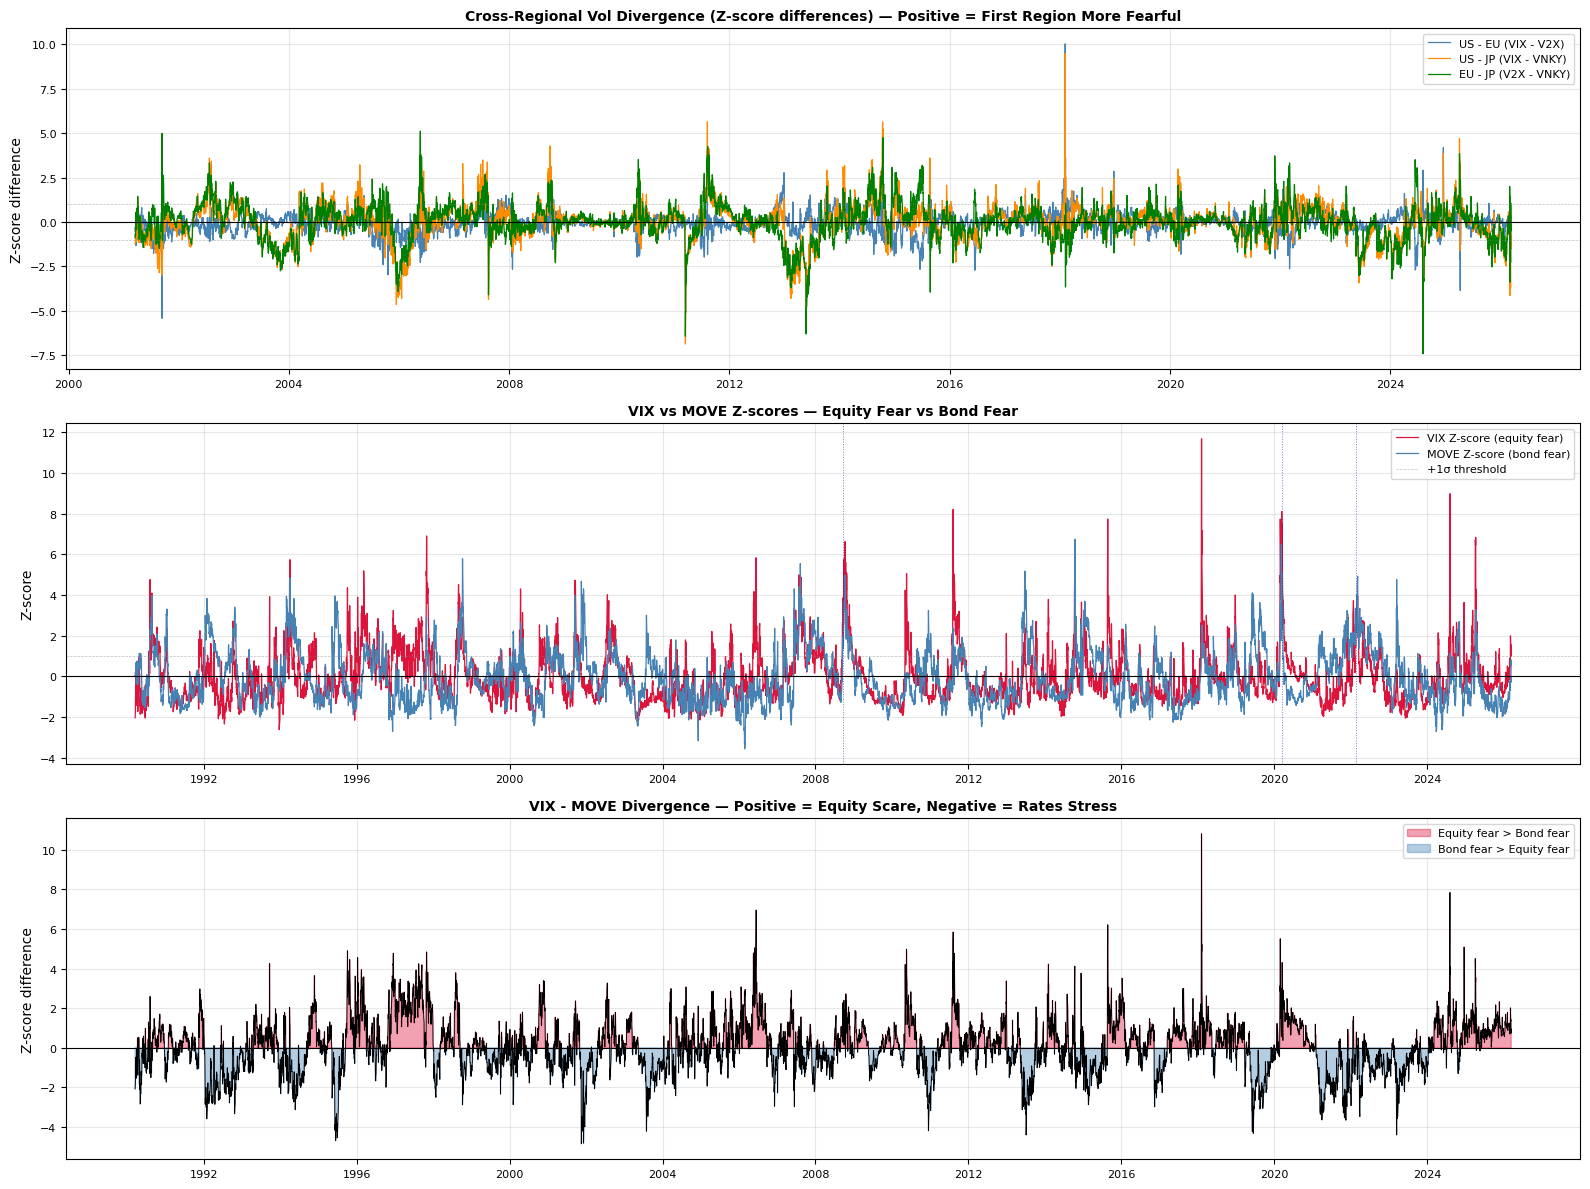

Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\02_branch1_divergence.png


In [3]:
# ── Step 3: Cross-regional divergence and VIX-MOVE analysis ──────────────────

# ── 3A: Cross-regional vol divergence ────────────────────────────────────────
# When vol indices across regions diverge strongly, it tells us WHERE
# the stress is originating and whether it is spreading or contained
# 
# Key divergences to track:
#   VIX vs V2X    — US vs Europe
#   VIX vs VNKY   — US vs Japan  
#   V2X vs VNKY   — Europe vs Japan

# Align all three on common dates
cross_vol = fear_levels[["VIX Index", "V2X Index", "VNKY Index"]].dropna()

# Compute rolling z-scores for each (1Y window)
def rolling_zscore(series, window=252):
    m = series.rolling(window, min_periods=63).mean()
    s = series.rolling(window, min_periods=63).std()
    return (series - m) / s

vix_z  = rolling_zscore(cross_vol["VIX Index"])
v2x_z  = rolling_zscore(cross_vol["V2X Index"])
vnky_z = rolling_zscore(cross_vol["VNKY Index"])

# Divergence = difference in z-scores
# Positive = first market more fearful than second
us_eu_div  = vix_z  - v2x_z    # Positive = US more fearful than EU
us_jp_div  = vix_z  - vnky_z   # Positive = US more fearful than Japan
eu_jp_div  = v2x_z  - vnky_z   # Positive = EU more fearful than Japan

print("Cross-Regional Vol Divergence (Z-score differences)")
print("Positive = first region more fearful than second")
print("-"*55)
print(f"  US vs EU  (VIX - V2X)  : {us_eu_div.dropna().iloc[-1]:+.2f}  "
      f"({'US more fearful' if us_eu_div.dropna().iloc[-1] > 0 else 'EU more fearful'})")
print(f"  US vs JP  (VIX - VNKY) : {us_jp_div.dropna().iloc[-1]:+.2f}  "
      f"({'US more fearful' if us_jp_div.dropna().iloc[-1] > 0 else 'JP more fearful'})")
print(f"  EU vs JP  (V2X - VNKY) : {eu_jp_div.dropna().iloc[-1]:+.2f}  "
      f"({'EU more fearful' if eu_jp_div.dropna().iloc[-1] > 0 else 'JP more fearful'})")


# ── 3B: VIX-MOVE divergence ───────────────────────────────────────────────────
# One of the most powerful signals in macro:
# VIX = equity fear, MOVE = bond/rates fear
# When they diverge, it tells you what TYPE of risk event is happening
#
# VIX high, MOVE low = equity selloff, rates market not worried = growth scare
# VIX low, MOVE high = rates crisis, equity not worried yet = early warning
# Both high = full financial crisis (2008, 2020)
# Both low  = goldilocks, complacency

vix_move = fear_levels[["VIX Index", "MOVE Index"]].dropna()

vix_move_vix_z  = rolling_zscore(vix_move["VIX Index"])
vix_move_move_z = rolling_zscore(vix_move["MOVE Index"])

# Divergence: positive = equity fear > bond fear
vix_move_div = vix_move_vix_z - vix_move_move_z

current_vix_z   = vix_move_vix_z.dropna().iloc[-1]
current_move_z  = vix_move_move_z.dropna().iloc[-1]
current_div     = vix_move_div.dropna().iloc[-1]

def classify_vix_move(vix_z, move_z):
    high_vix  = vix_z  > 1.0
    high_move = move_z > 1.0
    if   high_vix and high_move:      return "FULL CRISIS — both equity and bond fear elevated"
    elif high_vix and not high_move:  return "EQUITY/GROWTH SCARE — rates market still calm"
    elif not high_vix and high_move:  return "RATES STRESS — early warning, equity not pricing it yet"
    else:                             return "GOLDILOCKS — both calm"

regime_label = classify_vix_move(current_vix_z, current_move_z)

print(f"\nVIX-MOVE Divergence Analysis:")
print(f"  VIX Z-score  : {current_vix_z:+.2f}")
print(f"  MOVE Z-score : {current_move_z:+.2f}")
print(f"  Divergence   : {current_div:+.2f}")
print(f"  Regime type  : {regime_label}")


# ── 3C: Historical context — when was the fear score this high before? ────────
# Find all historical periods where fear score was above current level
current_fear = fear_score.dropna().iloc[-1]
high_fear_periods = fear_score[fear_score >= current_fear].dropna()

print(f"\nHistorical dates when Fear Score >= current ({current_fear:.1f}):")
# Group into episodes (cluster dates within 30 days together)
if len(high_fear_periods) > 0:
    episodes = []
    current_episode_start = high_fear_periods.index[0]
    current_episode_end   = high_fear_periods.index[0]
    for date in high_fear_periods.index[1:]:
        if (date - current_episode_end).days <= 30:
            current_episode_end = date
        else:
            episodes.append((current_episode_start, current_episode_end))
            current_episode_start = date
            current_episode_end   = date
    episodes.append((current_episode_start, current_episode_end))
    
    for start, end in episodes[-15:]:  # Show last 15 episodes
        peak_score = fear_score[start:end].max()
        print(f"  {str(start.date())} -> {str(end.date())}  "
              f"Peak: {peak_score:.1f}")


# ── 3D: Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Top: Cross-regional divergence
ax1 = axes[0]
ax1.plot(us_eu_div.index,  us_eu_div.values,  lw=0.9, color="steelblue",  label="US - EU (VIX - V2X)")
ax1.plot(us_jp_div.index,  us_jp_div.values,  lw=0.9, color="darkorange", label="US - JP (VIX - VNKY)")
ax1.plot(eu_jp_div.index,  eu_jp_div.values,  lw=0.9, color="green",      label="EU - JP (V2X - VNKY)")
ax1.axhline(0,  color="black", lw=0.8)
ax1.axhline(1,  color="grey",  lw=0.5, ls="--", alpha=0.5)
ax1.axhline(-1, color="grey",  lw=0.5, ls="--", alpha=0.5)
ax1.set_title("Cross-Regional Vol Divergence (Z-score differences) — Positive = First Region More Fearful",
              fontsize=10, fontweight="bold")
ax1.set_ylabel("Z-score difference")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8)

# Middle: VIX vs MOVE z-scores
ax2 = axes[1]
ax2.plot(vix_move_vix_z.index,  vix_move_vix_z.values,  lw=0.9, color="crimson",    label="VIX Z-score (equity fear)")
ax2.plot(vix_move_move_z.index, vix_move_move_z.values, lw=0.9, color="steelblue",  label="MOVE Z-score (bond fear)")
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(1, color="grey",  lw=0.5, ls="--", alpha=0.5, label="+1σ threshold")
for crisis_date, label in [("2008-09-15","GFC"),("2020-03-16","Covid"),("2022-02-24","Ukraine")]:
    try:
        ax2.axvline(pd.Timestamp(crisis_date), color="navy", lw=0.7, ls=":", alpha=0.5)
    except: pass
ax2.set_title("VIX vs MOVE Z-scores — Equity Fear vs Bond Fear",
              fontsize=10, fontweight="bold")
ax2.set_ylabel("Z-score")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8)

# Bottom: VIX-MOVE divergence
ax3 = axes[2]
ax3.fill_between(vix_move_div.index, vix_move_div.values, 0,
                 where=vix_move_div.values > 0,
                 alpha=0.4, color="crimson",   label="Equity fear > Bond fear")
ax3.fill_between(vix_move_div.index, vix_move_div.values, 0,
                 where=vix_move_div.values <= 0,
                 alpha=0.4, color="steelblue", label="Bond fear > Equity fear")
ax3.plot(vix_move_div.index, vix_move_div.values, lw=0.6, color="black")
ax3.axhline(0, color="black", lw=0.8)
ax3.set_title("VIX - MOVE Divergence — Positive = Equity Scare, Negative = Rates Stress",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Z-score difference")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "02_branch1_divergence.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

In [4]:
# ── Step 4: Branch 1 Final Summary ───────────────────────────────────────────

from datetime import timedelta

# ── Pull all current readings ─────────────────────────────────────────────────
latest = fear_levels.dropna(how="all").index[-1]

# Fear score and regime
cur_score  = fear_score.loc[latest] if latest in fear_score.index else fear_score.dropna().iloc[-1]
cur_regime = classify_fear_regime(cur_score)

# Z-scores
cur_zscores = {}
for col in FEAR_TICKERS:
    z = fear_zscore[col].dropna()
    if not z.empty:
        cur_zscores[col] = z.iloc[-1]

# Term structure
ts_latest   = term_structure.dropna().index[-1]
ts_vals     = term_structure.loc[ts_latest]
ts_slope    = term_slope.loc[ts_latest] if ts_latest in term_slope.index else float('nan')

# VIX-MOVE
cur_vix_z   = vix_move_vix_z.dropna().iloc[-1]
cur_move_z  = vix_move_move_z.dropna().iloc[-1]
cur_vm_type = classify_vix_move(cur_vix_z, cur_move_z)

# Cross-regional
cur_us_eu   = us_eu_div.dropna().iloc[-1]
cur_us_jp   = us_jp_div.dropna().iloc[-1]
cur_eu_jp   = eu_jp_div.dropna().iloc[-1]

# How many days have we been in current regime?
recent_regime = fear_regime.dropna()
current_streak = 0
for r in reversed(recent_regime.values):
    if r == cur_regime:
        current_streak += 1
    else:
        break

# Where does current score rank historically (all time percentile)
all_time_pctile = (fear_score.dropna() < cur_score).sum() / len(fear_score.dropna()) * 100

print("=" * 62)
print("   BRANCH 1 — FEAR & VOLATILITY REPORT")
print(f"   As of {latest.date()}")
print("=" * 62)

print(f"\n  GLOBAL FEAR SCORE  :  {cur_score:.1f} / 100")
print(f"  REGIME             :  {cur_regime}")
print(f"  REGIME STREAK      :  {current_streak} days in {cur_regime}")
print(f"  ALL-TIME PERCENTILE:  {all_time_pctile:.1f}th percentile")

print(f"\n  ── Indicator Z-scores ──────────────────────────────")
for col in FEAR_TICKERS:
    if col in cur_zscores:
        z   = cur_zscores[col]
        lvl = fear_levels[col].dropna().iloc[-1]
        reg = "ACUTE" if z > 2 else "ELEVATED" if z > 1 else "CALM" if z < -0.5 else "NORMAL"
        bar = "█" * min(int(abs(z) * 2), 12)
        print(f"  {col:<20} {lvl:>8.2f}   Z={z:>+5.2f}  {bar:<12}  [{reg}]")

print(f"\n  ── VIX Term Structure ──────────────────────────────")
print(f"  VIX9D  : {ts_vals.get('VIX9D Index', float('nan')):>6.2f}")
print(f"  VIX30D : {ts_vals.get('VIX Index',   float('nan')):>6.2f}")
print(f"  VIX3M  : {ts_vals.get('VIX3M Index', float('nan')):>6.2f}")
print(f"  VIX6M  : {ts_vals.get('VIX6M Index', float('nan')):>6.2f}")
slope_desc = "INVERTED — acute immediate stress" if ts_slope > 0 else "NORMAL — future uncertainty"
print(f"  Slope  : {ts_slope:>+6.2f}  ({slope_desc})")

print(f"\n  ── VIX-MOVE Divergence ─────────────────────────────")
print(f"  VIX Z  : {cur_vix_z:>+6.2f}   MOVE Z : {cur_move_z:>+6.2f}")
print(f"  Type   : {cur_vm_type}")

print(f"\n  ── Cross-Regional Fear Origin ──────────────────────")
print(f"  US vs EU   : {cur_us_eu:>+5.2f}  ({'US leads' if cur_us_eu > 0.3 else 'EU leads' if cur_us_eu < -0.3 else 'Synchronised'})")
print(f"  US vs JP   : {cur_us_jp:>+5.2f}  ({'US leads' if cur_us_jp > 0.3 else 'JP leads' if cur_us_jp < -0.3 else 'Synchronised'})")
print(f"  EU vs JP   : {cur_eu_jp:>+5.2f}  ({'EU leads' if cur_eu_jp > 0.3 else 'JP leads' if cur_eu_jp < -0.3 else 'Synchronised'})")

# Most fearful region
divergences = {"US": 0, "EU": -cur_us_eu, "JP": -cur_us_jp}
most_fearful = max(divergences, key=divergences.get)
print(f"\n  Most fearful region : {most_fearful}")

print(f"\n  ── Closest Historical Analogues ────────────────────")
# Find top 5 most similar historical periods by fear score proximity
score_series  = fear_score.dropna()
window_scores = score_series.rolling(5).mean().dropna()
today_score   = cur_score
diffs         = (window_scores - today_score).abs().sort_values()
# Exclude recent 90 days
diffs         = diffs[diffs.index < (latest - timedelta(days=90))]
shown = []
for date, diff in diffs.items():
    # Don't show dates within 60 days of already shown dates
    if all(abs((date - d).days) > 60 for d in shown):
        regime_then = fear_regime.get(date, "N/A")
        vix_then    = fear_levels["VIX Index"].get(date, float('nan'))
        print(f"  {str(date.date())}  Score={score_series.get(date,0):.1f}  "
              f"Regime={regime_then:<10}  VIX={vix_then:.1f}")
        shown.append(date)
    if len(shown) >= 5:
        break

print("\n" + "=" * 62)
print("  Branch 1 complete. Output saved to data/processed/regimes/")
print("=" * 62)

   BRANCH 1 — FEAR & VOLATILITY REPORT
   As of 2026-03-13

  GLOBAL FEAR SCORE  :  83.1 / 100
  REGIME             :  ACUTE
  REGIME STREAK      :  8 days in ACUTE
  ALL-TIME PERCENTILE:  92.7th percentile

  ── Indicator Z-scores ──────────────────────────────
  VIX Index               27.19   Z=+1.52  ███           [ELEVATED]
  VIX9D Index             28.00   Z=+1.36  ██            [ELEVATED]
  VIX3M Index             27.28   Z=+1.75  ███           [ELEVATED]
  VIX6M Index             27.43   Z=+1.92  ███           [ELEVATED]
  V2X Index               30.33   Z=+2.38  ████          [ACUTE]
  V1X Index               29.07   Z=+2.46  ████          [ACUTE]
  VNKY Index              45.80   Z=+2.87  █████         [ACUTE]
  VHSI Index              26.42   Z=+0.95  █             [NORMAL]
  MOVE Index              91.17   Z=+0.58  █             [NORMAL]
  SKEW Index             137.76   Z=-1.04  ██            [CALM]
  CPCE Index               0.58   Z=-0.08                [NORMAL]

  ── VI